# HQSNet

In questo notebook viene addestrato e testato un modello HQSNet per il problema di motion deblurring e denoising.

Il modello utilizza una DRUNet pre-addestrata come prior congelato e apprende i parametri dell’algoritmo unrolled HQS.

In [ ]:
# 1 - Download, preprocess and split the dataset if necessary. Then create the model

from datasets import load_dataset
import torch
from torch.utils.data import Subset

from utilities.image_dataset import ImageDataset
from utilities.degradation import ImageDegradation, DegradationParameters, RGBBlurOperator
from utilities.config import TRAIN_SIZE, VALIDATION_SIZE, TEST_SIZE
from models.network_unet import UNetRes
from models.network_hqs_net import DRUNetPrior, HQSNet, HQSNetTrainer


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DRUNET_PATH = "./weights/DRUNet/drunet_color.pth"
CHECKPOINT_PATH = "./weights/HQSNet/HQS_checkpoint.pth"


ds = load_dataset(
    "benjamin-paine/imagenet-1k-256x256"
)

train_dataset = Subset(
    ImageDataset(ds["train"]),
    range(TRAIN_SIZE),
)

validation_dataset = Subset(
    ImageDataset(ds["validation"]),
    range(VALIDATION_SIZE),
)

test_dataset = Subset(
    ImageDataset(ds["test"]),
    range(TEST_SIZE),
)


restoration_degradation = ImageDegradation(
    DegradationParameters(
        image_size=256,
        kernel_type="motion",
        kernel_size=9,
        motion_angle=45.0,
    )
)

K_rgb = RGBBlurOperator(
    restoration_degradation.operator
)


drunet = UNetRes(
    in_nc=4,
    out_nc=3,
    nc=[64, 128, 256, 512],
    nb=4,
    act_mode="R",
    downsample_mode="strideconv",
    upsample_mode="convtranspose",
    bias=False,
)

state_dict = torch.load(
    DRUNET_PATH,
    map_location=device,
    weights_only=False,
)

drunet.load_state_dict(state_dict, strict=True)
drunet.to(device)
drunet.eval()


prior = DRUNetPrior(
    model=drunet,
    freeze=True,
)

hqsnet = HQSNet(
    K=K_rgb,
    prior=prior,
    n_layers=8,
    initial_alpha=0.1,
    initial_sigma=25.0 / 255.0,
    init_mode="degraded",
).to(device)

trainer = HQSNetTrainer(hqsnet)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/36 [00:00<?, ?it/s]

## Training

Il modello viene addestrato su immagini degradate con motion blur e rumore gaussiano.

Durante il training la DRUNet rimane congelata. Vengono appresi solo i parametri per-layer dell’algoritmo HQS.

Epoch 1/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 1/50 | train_loss: 0.029005 | val_loss: 0.035831 | val_PSNR: 25.9256 | val_SSIM: 0.7399 | lr: 3.00e-03
{'alpha': [2.8942604064941406, 2.738630771636963, 3.098203659057617, 2.85343337059021, 2.1484851837158203, 1.4696779251098633, 1.093813419342041, 0.795383632183075], 'sigma': [0.14480619132518768, 0.19869926571846008, 0.033011097460985184, 0.01784476451575756, 0.023009177297353745, 0.04833431541919708, 0.03256973624229431, 0.015052590519189835], 'sigma_255': [36.92557878792286, 50.66831275820732, 8.417829852551222, 4.550414951518178, 5.867340210825205, 12.325250431895256, 8.30528274178505, 3.838410582393408]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 2/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 2/50 | train_loss: 0.025151 | val_loss: 0.034279 | val_PSNR: 26.3597 | val_SSIM: 0.7531 | lr: 3.00e-03
{'alpha': [1.3832194805145264, 4.854283809661865, 3.9473555088043213, 3.2621846199035645, 2.1663005352020264, 1.112607479095459, 1.1533751487731934, 0.7054052948951721], 'sigma': [0.20684368908405304, 0.575985312461853, 0.020183388143777847, 0.005806771572679281, 0.007375109940767288, 0.07140716910362244, 0.03259236365556717, 0.012959475629031658], 'sigma_255': [52.745140716433525, 146.87625467777252, 5.146763976663351, 1.4807267510332167, 1.8806530348956585, 18.20882812142372, 8.311052732169628, 3.304666285403073]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 3/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 3/50 | train_loss: 0.024837 | val_loss: 0.034121 | val_PSNR: 26.4704 | val_SSIM: 0.7523 | lr: 3.00e-03
{'alpha': [1.3936641216278076, 5.452710151672363, 5.906336784362793, 2.1191651821136475, 2.0955264568328857, 1.0693637132644653, 1.1655219793319702, 0.6287964582443237], 'sigma': [0.1956273764371872, 0.5759231448173523, 0.008290720172226429, 0.00231315940618515, 0.003355863504111767, 0.07300689071416855, 0.030263500288128853, 0.009959005750715733], 'sigma_255': [49.884980991482735, 146.86040192842484, 2.1141336439177394, 0.5898556485772133, 0.8557451935485005, 18.61675713211298, 7.7171925734728575, 2.539546466432512]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 4/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 4/50 | train_loss: 0.024500 | val_loss: 0.033894 | val_PSNR: 26.6009 | val_SSIM: 0.7524 | lr: 3.00e-03
{'alpha': [1.3628826141357422, 5.810523986816406, 7.887597560882568, 1.391195297241211, 3.270219326019287, 1.0326234102249146, 1.1932651996612549, 0.5804253220558167], 'sigma': [0.19228991866111755, 0.5973482728004456, 0.004018627572804689, 0.001400070614181459, 0.001624019118025899, 0.0825340524315834, 0.029391393065452576, 0.007218081969767809], 'sigma_255': [49.033929258584976, 152.32380956411362, 1.0247500310651958, 0.35701800661627203, 0.41412487509660423, 21.046183370053768, 7.494805231690407, 1.8406109022907913]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 5/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 5/50 | train_loss: 0.024377 | val_loss: 0.033762 | val_PSNR: 26.6421 | val_SSIM: 0.7538 | lr: 3.00e-03
{'alpha': [1.330428123474121, 5.614570140838623, 9.132046699523926, 1.3879355192184448, 3.1411590576171875, 1.0174874067306519, 1.2346246242523193, 0.5063796639442444], 'sigma': [0.19607429206371307, 0.5810385346412659, 0.001621575909666717, 0.000986498431302607, 0.0008673644624650478, 0.08876383304595947, 0.031621430069208145, 0.00649314746260643], 'sigma_255': [49.998944476246834, 148.1648263335228, 0.41350185696501285, 0.2515570999821648, 0.2211779379285872, 22.634777426719666, 8.063464667648077, 1.6557526029646397]}


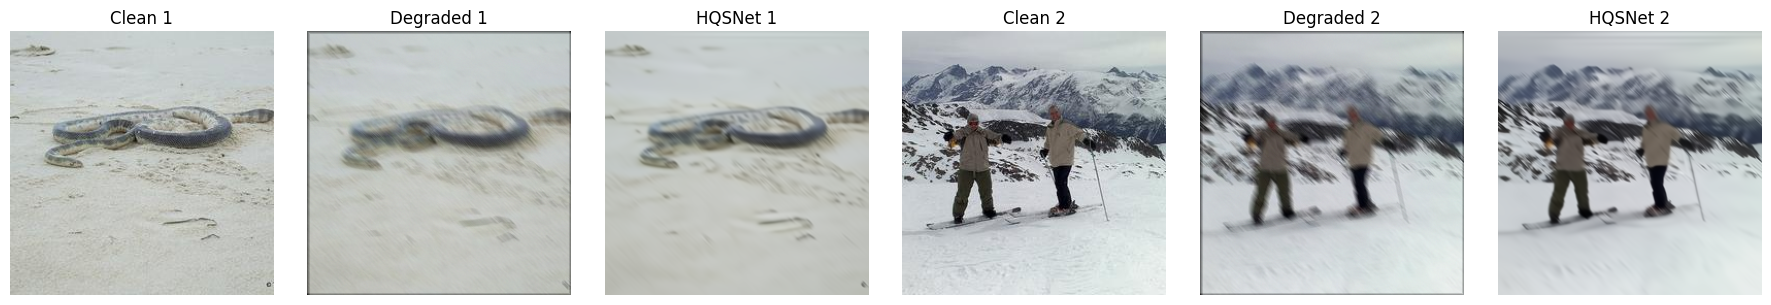

Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 6/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 6/50 | train_loss: 0.024251 | val_loss: 0.033635 | val_PSNR: 26.6777 | val_SSIM: 0.7556 | lr: 3.00e-03
{'alpha': [1.3192744255065918, 5.259411811828613, 10.238100051879883, 1.3914368152618408, 2.925644636154175, 1.0157701969146729, 1.260658621788025, 0.47502920031547546], 'sigma': [0.19781886041164398, 0.5735279321670532, 0.0005088666221126914, 0.0005793978343717754, 0.0004729950160253793, 0.09541577100753784, 0.03308315947651863, 0.005974218714982271], 'sigma_255': [50.443809404969215, 146.24962270259857, 0.1297609886387363, 0.14774644776480272, 0.12061372908647172, 24.33102160692215, 8.436205666512251, 1.5234257723204792]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 7/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 7/50 | train_loss: 0.024132 | val_loss: 0.033760 | val_PSNR: 26.6884 | val_SSIM: 0.7548 | lr: 3.00e-03
{'alpha': [1.314092755317688, 4.93497896194458, 11.240087509155273, 1.4062498807907104, 2.7184245586395264, 0.9975547790527344, 1.3517444133758545, 0.5161169171333313], 'sigma': [0.20710140466690063, 0.5506203770637512, 0.0001467013789806515, 0.00031309074256569147, 0.000262388406554237, 0.10009536147117615, 0.03164594620466232, 0.005162240006029606], 'sigma_255': [52.81085819005966, 140.40819615125656, 0.03740885164006613, 0.07983813935425133, 0.06690904367133044, 25.524317175149918, 8.069716282188892, 1.3163712015375495]}


...

Epoch 8/50 | train_loss: 0.024113 | val_loss: 0.033628 | val_PSNR: 26.7130 | val_SSIM: 0.7557 | lr: 3.00e-03
{'alpha': [1.3048732280731201, 4.752839088439941, 12.04074478149414, 1.40023934841156, 2.7502782344818115, 0.9929240345954895, 1.306330680847168, 0.49221402406692505], 'sigma': [0.20531034469604492, 0.5292213559150696, 4.452632856555283e-05, 0.0001609189057489857, 0.00014999070845078677, 0.10522192716598511, 0.03382592275738716, 0.005484782159328461], 'sigma_255': [52.354137897491455, 134.95144575834274, 0.011354213784215972, 0.041034320965991355, 0.038247630654950626, 26.831591427326202, 8.625610303133726, 1.3986194506287575]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 9/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 9/50 | train_loss: 0.024121 | val_loss: 0.033546 | val_PSNR: 26.7382 | val_SSIM: 0.7573 | lr: 3.00e-03
{'alpha': [1.2868351936340332, 4.649199962615967, 12.73715591430664, 1.404438853263855, 2.623744010925293, 0.9951160550117493, 1.3399511575698853, 0.5055756568908691], 'sigma': [0.20531058311462402, 0.518240749835968, 1.4590769751521293e-05, 8.217169670388103e-05, 8.625935151940212e-05, 0.11065302044153214, 0.03401525318622589, 0.005466389935463667], 'sigma_255': [52.354198694229126, 132.15139120817184, 0.0037206462866379297, 0.02095378265948966, 0.02199613463744754, 28.216520212590694, 8.673889562487602, 1.393929433543235]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 10/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 10/50 | train_loss: 0.024014 | val_loss: 0.033818 | val_PSNR: 26.7118 | val_SSIM: 0.7534 | lr: 3.00e-03
{'alpha': [1.2947564125061035, 4.652272701263428, 13.413089752197266, 1.3854331970214844, 2.6593101024627686, 1.0085846185684204, 1.36056387424469, 0.5265807509422302], 'sigma': [0.199493408203125, 0.4866991937160492, 5.3159687922743615e-06, 3.960931280744262e-05, 4.810647442354821e-05, 0.11085141450166702, 0.03367623686790466, 0.005595487076789141], 'sigma_255': [50.870819091796875, 124.10829439759254, 0.0013555720420299622, 0.010100374765897868, 0.012267150978004793, 28.26711069792509, 8.587440401315689, 1.4268492045812309]}


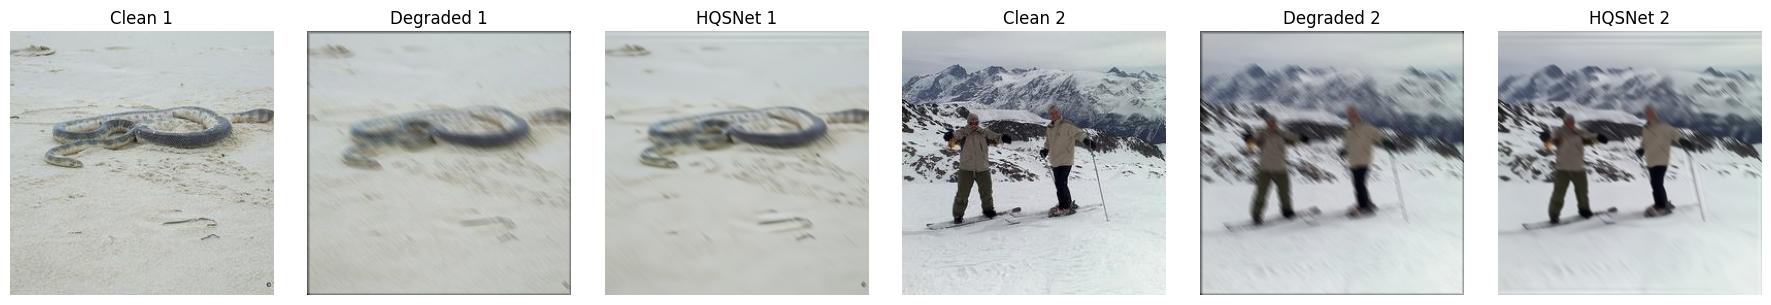

Epoch 11/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 11/50 | train_loss: 0.024065 | val_loss: 0.033228 | val_PSNR: 26.7908 | val_SSIM: 0.7606 | lr: 3.00e-03
{'alpha': [1.3073595762252808, 4.628381252288818, 13.916400909423828, 1.3805699348449707, 2.571427583694458, 0.9975640177726746, 1.3263851404190063, 0.49337542057037354], 'sigma': [0.2031380981206894, 0.5088925957679749, 2.5791296138777398e-06, 2.091020178340841e-05, 2.9384853405645117e-05, 0.12262566387653351, 0.0367768257856369, 0.006328634452074766], 'sigma_255': [51.800215020775795, 129.7676119208336, 0.0006576780515388236, 0.005332101454769145, 0.007493137618439505, 31.269544288516045, 9.37809057533741, 1.6138017852790654]}
Saved best checkpoint to: ./weights/HQSNet/HQS_checkpoint_best.pth


Epoch 12/50:   0%|          | 0/2500 [00:00<?, ?it/s]

Epoch 12/50 | train_loss: 0.024069 | val_loss: 0.033484 | val_PSNR: 26.7711 | val_SSIM: 0.7574 | lr: 3.00e-03
{'alpha': [1.264769196510315, 4.53309440612793, 14.38540267944336, 1.3586757183074951, 2.5492687225341797, 0.9878320097923279, 1.3816295862197876, 0.5385636687278748], 'sigma': [0.19597114622592926, 0.4796985983848572, 1.6833863583087805e-06, 1.0625699360389262e-05, 1.7869546354631893e-05, 0.12109017372131348, 0.03581218793988228, 0.006152677349746227], 'sigma_255': [49.97264228761196, 122.32314258813858, 0.000429263521368739, 0.002709553336899262, 0.004556734320431133, 30.877994298934937, 9.132107924669981, 1.568932724185288]}


Epoch 13/50:   0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [2]:
# 2 - Train the HQSNet model

train_degradation = ImageDegradation(
    DegradationParameters(
        image_size=256,
        kernel_type="motion",
        kernel_size=9,
        motion_angle=45.0,
        noise_levels=[0.005, 0.01, 0.05, 0.1],
    )
)

validation_degradations = [
    ImageDegradation(
        DegradationParameters(
            image_size=256,
            kernel_type="motion",
            kernel_size=9,
            motion_angle=45.0,
            noise_levels=[0.005],
        )
    ),
    ImageDegradation(
        DegradationParameters(
            image_size=256,
            kernel_type="motion",
            kernel_size=9,
            motion_angle=45.0,
            noise_levels=[0.01],
        )
    ),
    ImageDegradation(
        DegradationParameters(
            image_size=256,
            kernel_type="motion",
            kernel_size=9,
            motion_angle=45.0,
            noise_levels=[0.05],
        )
    ),
    ImageDegradation(
        DegradationParameters(
            image_size=256,
            kernel_type="motion",
            kernel_size=9,
            motion_angle=45.0,
            noise_levels=[0.1],
        )
    ),
]


TRAIN_MODEL = True

if TRAIN_MODEL:
    hqs_history = trainer.train_model(
        n_epochs=50,
        train_dataset=train_dataset,
        validation_dataset=validation_dataset,
        train_degradation=train_degradation,
        validation_degradations=validation_degradations,
        batch_size=4,
        learning_rate=3e-3,
        checkpoint_path=CHECKPOINT_PATH,
        resume=False,
        preview_every=5,
        preview_n=2,
        max_validation_batches=10,
        device=device,
    )

## Evaluation

Viene caricato il miglior checkpoint salvato durante il training e il modello viene testato su una singola immagine del test set.

Loaded checkpoint: ./weights/HQSNet/HQS_checkpoint_best.pth
Checkpoint epoch: 10
Degraded | PSNR: 23.4588 | SSIM: 0.6080
HQSNet   | PSNR: 25.8300 | SSIM: 0.6980
{'alpha': [1.3073595762252808, 4.628381252288818, 13.916400909423828, 1.3805699348449707, 2.571427583694458, 0.9975640177726746, 1.3263851404190063, 0.49337542057037354], 'sigma': [0.2031380981206894, 0.5088925957679749, 2.5791296138777398e-06, 2.091020178340841e-05, 2.9384853405645117e-05, 0.12262566387653351, 0.0367768257856369, 0.006328634452074766], 'sigma_255': [51.800215020775795, 129.7676119208336, 0.0006576780515388236, 0.005332101454769145, 0.007493137618439505, 31.269544288516045, 9.37809057533741, 1.6138017852790654]}


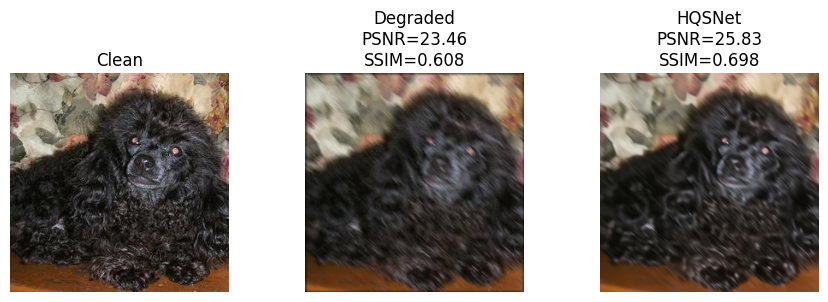

In [ ]:
# 3 - Load checkpoint and test on example index

from IPPy.utilities.metrics import PSNR, SSIM
from utilities.plotter import plot 


BEST_CHECKPOINT_PATH = CHECKPOINT_PATH.replace(".pth", "_best.pth")

checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False,
)

hqsnet.load_state_dict(checkpoint["model"])
hqsnet.eval()

print(f"Loaded checkpoint: {BEST_CHECKPOINT_PATH}")
print(f"Checkpoint epoch: {checkpoint['epoch']}")


example_index = 10
noise_level = 0.01

clean = test_dataset[example_index]

if isinstance(clean, tuple):
    clean = clean[0]

clean = clean.unsqueeze(0).to(device)


test_degradation = ImageDegradation(
    DegradationParameters(
        image_size=256,
        kernel_type="motion",
        kernel_size=9,
        motion_angle=45.0,
        noise_levels=[noise_level],
    )
)

with torch.no_grad():
    degraded = test_degradation(clean)
    restored = hqsnet.clipped_forward(degraded)


psnr_degraded = PSNR(degraded.float(), clean.float())
ssim_degraded = SSIM(degraded.float(), clean.float())

psnr_restored = PSNR(restored.float(), clean.float())
ssim_restored = SSIM(restored.float(), clean.float())

if isinstance(psnr_degraded, torch.Tensor):
    psnr_degraded = psnr_degraded.item()

if isinstance(ssim_degraded, torch.Tensor):
    ssim_degraded = ssim_degraded.item()

if isinstance(psnr_restored, torch.Tensor):
    psnr_restored = psnr_restored.item()

if isinstance(ssim_restored, torch.Tensor):
    ssim_restored = ssim_restored.item()


print(f"Degraded | PSNR: {psnr_degraded:.4f} | SSIM: {ssim_degraded:.4f}")
print(f"HQSNet   | PSNR: {psnr_restored:.4f} | SSIM: {ssim_restored:.4f}")

print(hqsnet.parameter_summary())


plot(
    clean[0].detach().cpu(),
    degraded[0].detach().cpu(),
    restored[0].detach().cpu(),
    titles=[
        "Clean",
        f"Degraded\nPSNR={psnr_degraded:.2f}\nSSIM={ssim_degraded:.3f}",
        f"HQSNet\nPSNR={psnr_restored:.2f}\nSSIM={ssim_restored:.3f}",
    ],
)